In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('car details v3.csv')

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [3]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [6]:
df['car_age'] = 2024 - df['year']

df[['name', 'year', 'car_age']].head()

,name,year,car_age
0,Maruti Swift Dzire VDI,2014,10
1,Skoda Rapid 1.5 TDI Ambition,2014,10
2,Honda City 2017-2020 EXi,2006,18
3,Hyundai i20 Sportz Diesel,2010,14
4,Maruti Swift VXI BSIII,2007,17


In [7]:
df['brand'] = df['name'].str.split().str[0]

df[['name', 'brand']].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


In [8]:
df['brand'].value_counts()

brand
Maruti           2367
Hyundai          1360
Mahindra          758
Tata              719
Honda             466
Toyota            452
Ford              388
Chevrolet         230
Renault           228
Volkswagen        185
BMW               118
Skoda             104
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               41
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Force               6
Land                6
Isuzu               5
Kia                 4
Ambassador          4
Daewoo              3
MG                  3
Ashok               1
Opel                1
Name: count, dtype: int64

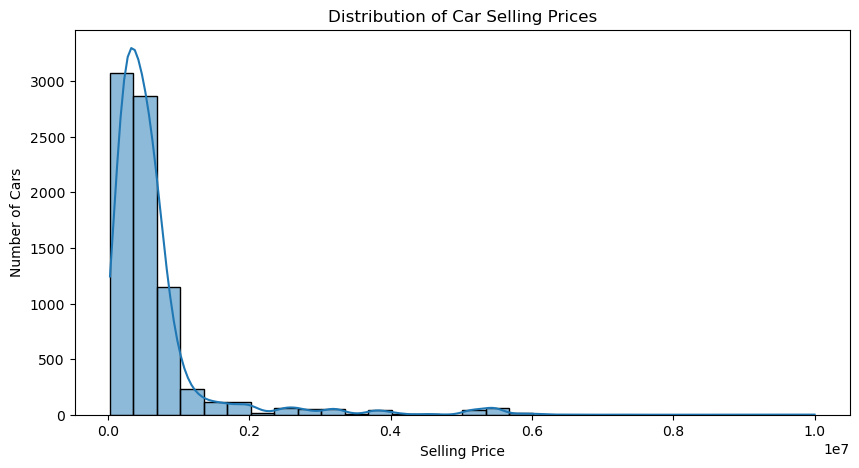

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

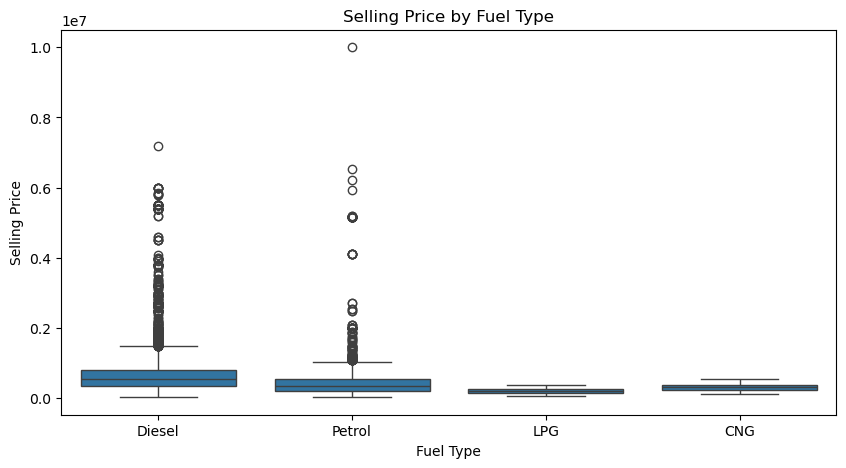

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(x='fuel', y='selling_price', data=df)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

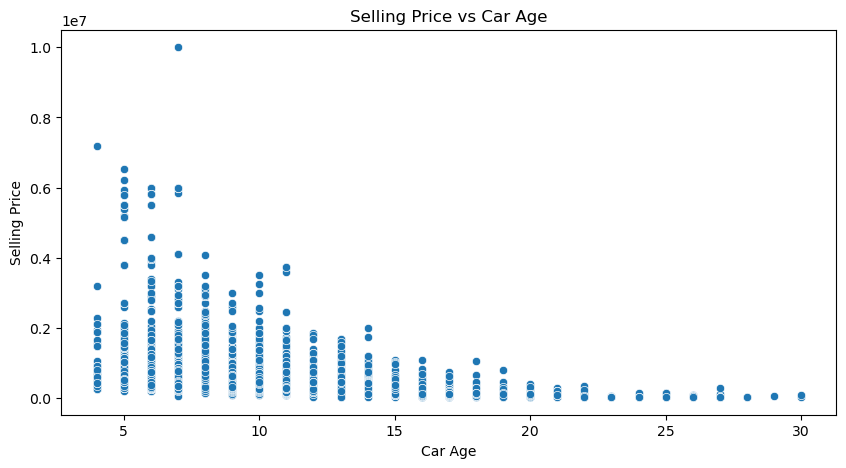

In [11]:
plt.figure(figsize=(10,5))

sns.scatterplot(x='car_age', y='selling_price', data=df)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

In [12]:
df_model = df.drop(columns=['name', 'torque'])

df_encoded = pd.get_dummies(
    df_model,
    columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'],
    drop_first=True
)

df_encoded.head()

,year,selling_price,km_driven,mileage,engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,23.4 kmpl,1248 CC,74 bhp,5.0,10,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2014,370000,120000,21.14 kmpl,1498 CC,103.52 bhp,5.0,10,True,False,...,False,False,False,False,False,True,False,False,False,False
2,2006,158000,140000,17.7 kmpl,1497 CC,78 bhp,5.0,18,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2010,225000,127000,23.0 kmpl,1396 CC,90 bhp,5.0,14,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2007,130000,120000,16.1 kmpl,1298 CC,88.2 bhp,5.0,17,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
df_model['mileage'] = df_model['mileage'].str.extract(r'([\d.]+)').astype(float)
df_model['engine'] = df_model['engine'].str.extract(r'([\d.]+)').astype(float)
df_model['max_power'] = df_model['max_power'].str.extract(r'([\d.]+)').astype(float)
df_model['seats'] = pd.to_numeric(df_model['seats'], errors='coerce')

In [15]:
df_model = df_model.dropna()

df_encoded = pd.get_dummies(
    df_model,
    columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'],
    drop_first=True
)

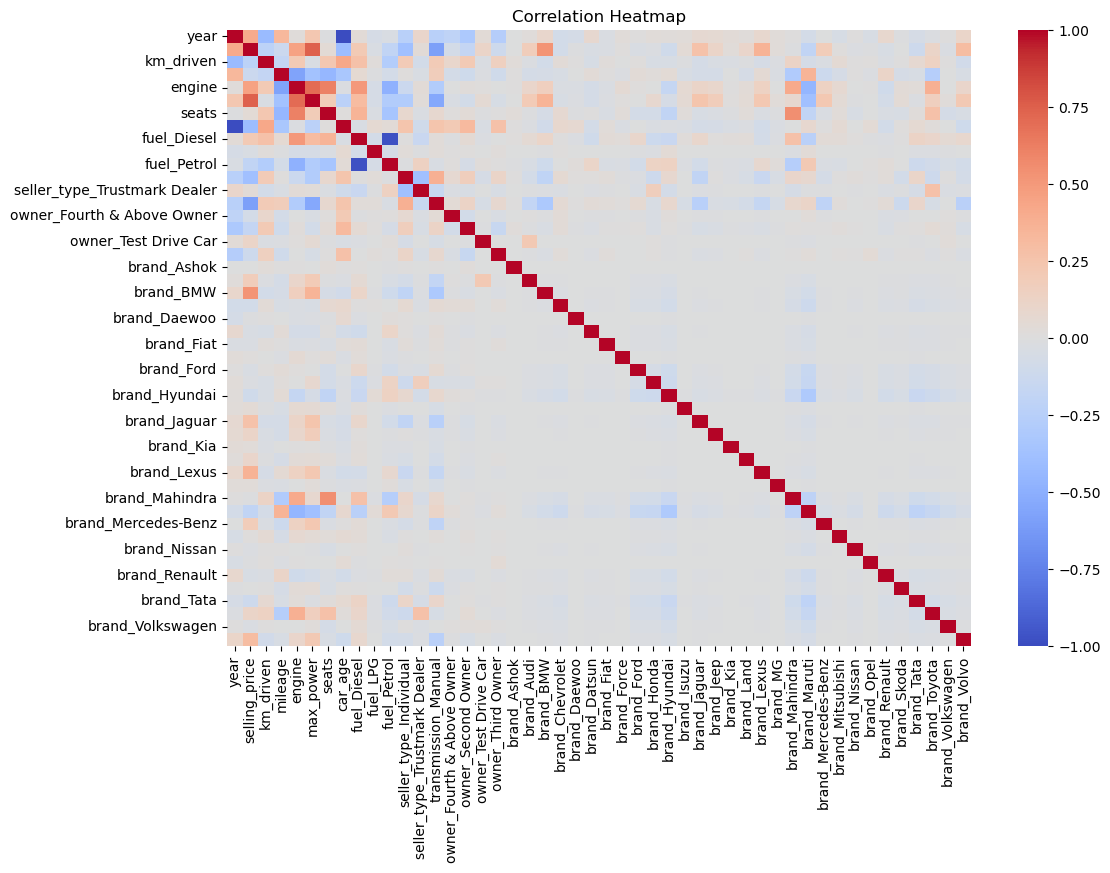

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [17]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7906, 47)
y shape: (7906,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6324, 47)
Testing data: (1582, 47)


In [19]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Linear Regression
MAE : 159713.65864155724
RMSE: 291270.2438143887
R2  : 0.8779801174711646

Random Forest
MAE : 59869.79074748096
RMSE: 102912.02557527149
R2  : 0.9847675200020829


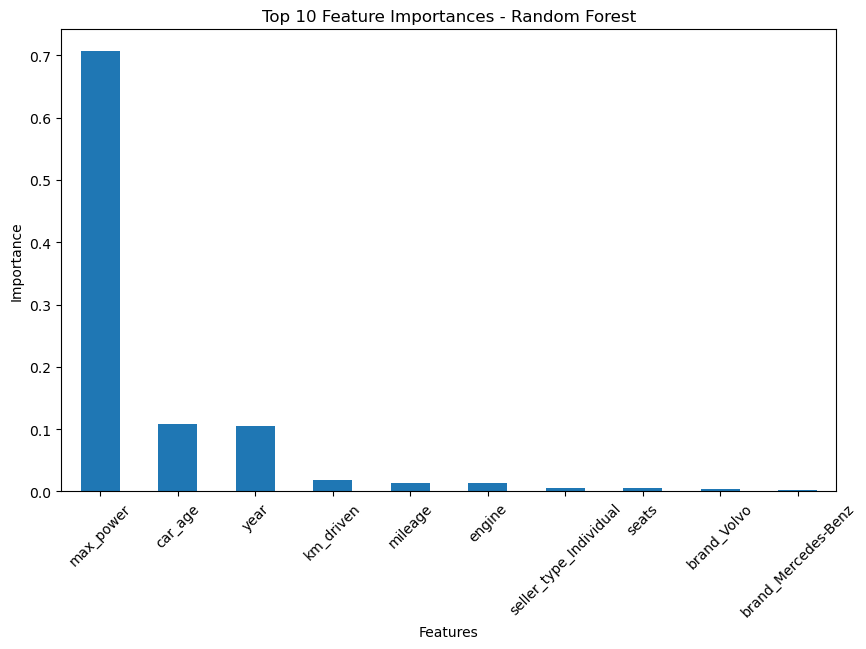

In [22]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind='bar')

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

## Conclusion

Two machine learning models were trained to predict car selling prices: Linear Regression and Random Forest Regression.

Random Forest performed better than Linear Regression, with a lower MAE and RMSE and a higher R² score.

The Random Forest model achieved an R² score of approximately 0.985, showing strong predictive performance on the test data.

The feature importance analysis identifies the most influential factors used by the model to predict car selling prices.